
# Recommendation Systems — The Math, Explained and Implemented

This notebook is the "show your work" companion to the animated slide deck. Every
method gets: **the intuition**, **the math derived step by step**, and **working
code you can run and inspect** — mostly built from scratch with plain NumPy so
nothing is hidden behind a library call.

We'll use one small, running example throughout: a toy catalog of **8 users** and
**10 movies**, so you can watch the same numbers flow through every method.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)
plt.rcParams['figure.facecolor'] = 'white'

users  = [f"U{i+1}" for i in range(8)]
movies = ["Explosion Quest", "Love in Paris", "Laugh Riot", "Space Odyssey",
          "Heartstrings", "Comedy Night", "Battle Zone", "Rom-Com Classic",
          "Deep Space", "Giggle Fest"]

# genre features per movie: [action, romance, comedy]  (content-based features)
item_features = np.array([
    [0.9, 0.05, 0.05],  # Explosion Quest
    [0.05, 0.9, 0.05],  # Love in Paris
    [0.05, 0.05, 0.9],  # Laugh Riot
    [0.85, 0.10, 0.05], # Space Odyssey
    [0.05, 0.85, 0.10], # Heartstrings
    [0.10, 0.05, 0.85], # Comedy Night
    [0.95, 0.02, 0.03], # Battle Zone
    [0.10, 0.80, 0.10], # Rom-Com Classic
    [0.80, 0.15, 0.05], # Deep Space
    [0.05, 0.10, 0.85], # Giggle Fest
])

# sparse ratings matrix, 1-5, NaN = unrated
R = np.array([
    [5, 2, 1, 4, 2, 1, np.nan, 1, 4, 1],
    [1, 5, 2, 1, 4, 2, 1, 5, 1, 2],
    [2, 1, 5, np.nan, 1, 4, 2, 1, 2, 5],
    [4, 1, 1, 5, 1, 1, 5, np.nan, 4, 1],
    [1, 4, 2, 1, 5, 2, 1, 4, 1, 2],
    [1, 2, 4, np.nan, 2, 5, 1, 2, 1, 4],
    [5, 1, 1, 4, np.nan, 1, 5, 1, 5, 1],
    [2, 5, 2, 1, 4, 2, 1, np.nan, 2, 2],
], dtype=float)

ratings_df = pd.DataFrame(R, index=users, columns=movies)
ratings_df


,Explosion Quest,Love in Paris,Laugh Riot,Space Odyssey,Heartstrings,Comedy Night,Battle Zone,Rom-Com Classic,Deep Space,Giggle Fest
U1,5.0,2.0,1.0,4.0,2.0,1.0,NaN,1.0,4.0,1.0
U2,1.0,5.0,2.0,1.0,4.0,2.0,1.0,5.0,1.0,2.0
U3,2.0,1.0,5.0,NaN,1.0,4.0,2.0,1.0,2.0,5.0
U4,4.0,1.0,1.0,5.0,1.0,1.0,5.0,NaN,4.0,1.0
U5,1.0,4.0,2.0,1.0,5.0,2.0,1.0,4.0,1.0,2.0
U6,1.0,2.0,4.0,NaN,2.0,5.0,1.0,2.0,1.0,4.0
U7,5.0,1.0,1.0,4.0,NaN,1.0,5.0,1.0,5.0,1.0
U8,2.0,5.0,2.0,1.0,4.0,2.0,1.0,NaN,2.0,2.0



## Math toolkit (quick recap)

Three pieces of notation carry almost this entire notebook:

**Summation** $\sum_{i} x_i$ just means "add up a list of numbers".

**Dot product** of two vectors $A,B \in \mathbb{R}^d$:
$$A \cdot B = \sum_{i=1}^{d} A_i B_i$$
Large & positive when $A,B$ point the same way, near zero when unrelated, negative
when opposite.

**Cosine similarity** normalizes the dot product by vector length, so it only
measures *direction*, not magnitude:
$$\cos(\theta) = \frac{A\cdot B}{\lVert A\rVert \lVert B\rVert}$$


In [2]:

def dot(a, b):
    return np.sum(a * b)  # elementwise multiply, then Σ

def cosine_sim(a, b):
    return dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

a = np.array([4, 3])
b = np.array([5, 2])
print(f"A·B (component-wise, then Σ) = {dot(a,b)}")
print(f"cosine similarity            = {cosine_sim(a,b):.3f}")


A·B (component-wise, then Σ) = 26
cosine similarity            = 0.966



## 1. Content-Based Filtering

**Idea:** describe every item as a feature vector. Describe the user as the
average of the feature vectors of items they rated highly. Recommend items whose
vectors point in a similar *direction* to the user's profile.

$$\text{user profile} = \frac{1}{|L|}\sum_{i \in L} \text{features}(i)
\qquad \text{score}(u, i) = \cos(\theta) \text{ between profile}_u \text{ and features}_i$$

where $L$ is the set of items the user rated $\geq 4$.


In [3]:

def content_based_recommend(user_row, item_features, movies, top_k=3):
    liked_idx = np.where(user_row >= 4)[0]
    liked_idx = liked_idx[~np.isnan(user_row[liked_idx])]
    profile = item_features[liked_idx].mean(axis=0)

    scores = np.array([cosine_sim(profile, item_features[i]) for i in range(len(movies))])
    unrated = np.where(np.isnan(user_row))[0]
    ranked = unrated[np.argsort(-scores[unrated])][:top_k]
    return profile, pd.Series(scores[ranked], index=[movies[i] for i in ranked], name="cosine score")

profile, recs = content_based_recommend(R[0], item_features, movies)
print("U1's inferred taste profile [action, romance, comedy]:", np.round(profile, 2))
print("\nTop content-based picks for U1 (unrated movies only):")
recs


U1's inferred taste profile [action, romance, comedy]: [0.85 0.1  0.05]

Top content-based picks for U1 (unrated movies only):


Battle Zone    0.995041
Name: cosine score, dtype: float64


## 2. Collaborative Filtering

**Idea:** no item features needed — just find users whose *pattern* of ratings
looks like yours, and borrow their opinions.

Because some people rate everything a 5 and others rarely go above a 3, we first
**mean-center** each user's ratings, then predict a missing rating as the user's
own average, nudged by similar users' relative opinions:

$$\hat r_{ui} = \bar r_u + \frac{\sum_{v} \text{sim}(u,v)\,(r_{vi} - \bar r_v)}
{\sum_{v} |\text{sim}(u,v)|}$$


In [4]:

def user_mean(R):
    return np.nanmean(R, axis=1)

def user_similarity(R):
    means = user_mean(R)
    centered = R - means[:, None]
    filled = np.nan_to_num(centered, nan=0.0)
    mask = (~np.isnan(R)).astype(float)
    # cosine similarity between users, computed only over co-rated items would be more
    # correct at scale; here we keep it simple and use the full mean-centered rows.
    n = R.shape[0]
    sim = np.zeros((n, n))
    for u in range(n):
        for v in range(n):
            sim[u, v] = cosine_sim(filled[u], filled[v]) if u != v else 0.0
    return sim, means

def predict_rating(R, u, i, sim, means):
    numer, denom = 0.0, 0.0
    for v in range(R.shape[0]):
        if v == u or np.isnan(R[v, i]):
            continue
        numer += sim[u, v] * (R[v, i] - means[v])
        denom += abs(sim[u, v])
    return means[u] + (numer / denom if denom > 0 else 0.0)

sim, means = user_similarity(R)
print("Most similar user to U1:", users[np.argmax(sim[0])], f"(sim={sim[0].max():.3f})")

missing = np.argwhere(np.isnan(R))
preds = [(users[u], movies[i], round(predict_rating(R, u, i, sim, means), 2)) for u, i in missing]
pd.DataFrame(preds, columns=["user", "movie", "predicted_rating"])


Most similar user to U1: U7 (sim=0.861)


,user,movie,predicted_rating
0,U1,Battle Zone,4.05
1,U3,Space Odyssey,2.53
2,U4,Rom-Com Classic,1.44
3,U6,Space Odyssey,0.75
4,U7,Heartstrings,1.75
5,U8,Rom-Com Classic,4.21



## 3. Loss functions — what are we actually minimizing?

Different training objectives teach a model different things:

$$\text{squared error: } (r-\hat r)^2 \qquad
\text{BPR ranking loss: } -\ln\sigma(\hat r_{\text{pos}} - \hat r_{\text{neg}})\qquad
\text{log-loss: } -[y\ln p + (1-y)\ln(1-p)]$$

Squared error cares about the *exact* number. BPR only cares about *relative
order* (did we rank the liked item above the unliked one?). Log-loss is the right
choice for "will they click, yes/no?" problems.


In [5]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def squared_error(r, r_hat):
    return (r - r_hat) ** 2

def bpr_loss(score_pos, score_neg):
    return -np.log(sigmoid(score_pos - score_neg) + 1e-12)

def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

print("squared error, r=5, r̂=3.2:", round(squared_error(5, 3.2), 3))
print("BPR loss, score_pos=2.1, score_neg=2.0 (barely separated):", round(bpr_loss(2.1, 2.0), 3))
print("BPR loss, score_pos=3.0, score_neg=0.1 (well separated):  ", round(bpr_loss(3.0, 0.1), 3))
print("log-loss, y=1, p=0.9 (confident & correct):", round(log_loss(1, 0.9), 3))
print("log-loss, y=1, p=0.1 (confident & wrong):  ", round(log_loss(1, 0.1), 3))


squared error, r=5, r̂=3.2: 3.24
BPR loss, score_pos=2.1, score_neg=2.0 (barely separated): 0.644
BPR loss, score_pos=3.0, score_neg=0.1 (well separated):   0.054
log-loss, y=1, p=0.9 (confident & correct): 0.105
log-loss, y=1, p=0.1 (confident & wrong):   2.303



## 4. Regularization — why models need a leash

With enough free parameters, a model can memorize training noise perfectly and
then generalize terribly. Regularization penalizes large parameter values:

$$\text{L2 (ridge): } \lambda\sum w_i^2 \quad\text{(smooth shrinkage)}\qquad
\text{L1 (lasso): } \lambda\sum |w_i| \quad\text{(many }w_i\to 0\text{)}$$

Below: fitting a high-degree polynomial to noisy data with no regularization vs.
with ridge regularization.


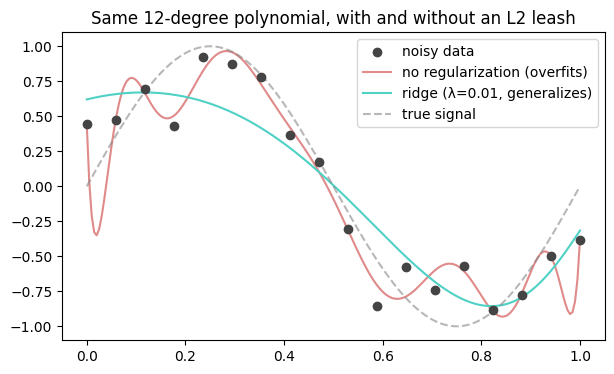

In [6]:

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(3)
x = np.linspace(0, 1, 18)
y_true = np.sin(2 * np.pi * x)
y = y_true + rng.normal(0, 0.25, size=x.shape)

x_grid = np.linspace(0, 1, 200).reshape(-1, 1)

overfit = make_pipeline(PolynomialFeatures(12), LinearRegression()).fit(x.reshape(-1,1), y)
regularized = make_pipeline(PolynomialFeatures(12), Ridge(alpha=0.01)).fit(x.reshape(-1,1), y)

fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(x, y, color='#444', label='noisy data', zorder=5)
ax.plot(x_grid, overfit.predict(x_grid), color='#e08a8a', label='no regularization (overfits)')
ax.plot(x_grid, regularized.predict(x_grid), color='#4fd1c5', label='ridge (λ=0.01, generalizes)')
ax.plot(x_grid, np.sin(2*np.pi*x_grid), '--', color='#888', label='true signal', alpha=0.6)
ax.legend(); ax.set_title("Same 12-degree polynomial, with and without an L2 leash")
plt.show()



## 5. Matrix Factorization

**Idea:** assume ratings come from a small number of hidden ("latent") taste
factors. Factor the sparse ratings matrix $R$ into two thin matrices $P$ (users
× factors) and $Q$ (items × factors) so that $R \approx PQ^T$.

Training minimizes regularized squared error over the *observed* ratings only:

$$\min_{P,Q} \sum_{(u,i)\in R} (r_{ui} - p_u\cdot q_i)^2 + \lambda(\lVert p_u\rVert^2 + \lVert q_i\rVert^2)$$

We train with **stochastic gradient descent**: for every observed rating, compute
the error, then nudge $p_u$ and $q_i$ a little downhill:

$$e_{ui} = r_{ui} - p_u\cdot q_i \qquad
p_u \leftarrow p_u + \eta(e_{ui}\,q_i - \lambda p_u) \qquad
q_i \leftarrow q_i + \eta(e_{ui}\,p_u - \lambda q_i)$$


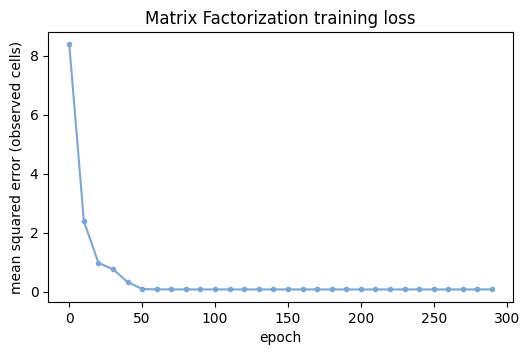


Reconstructed rating matrix (rounded), including previously-missing cells:


,Explosion Quest,Love in Paris,Laugh Riot,Space Odyssey,Heartstrings,Comedy Night,Battle Zone,Rom-Com Classic,Deep Space,Giggle Fest
U1,4.46,1.80,1.01,4.05,1.89,0.97,4.56,1.28,4.16,1.01
U2,1.21,4.68,1.95,0.82,4.35,2.09,0.82,4.50,1.16,1.96
U3,1.94,1.01,4.53,2.77,1.09,4.44,2.06,0.99,1.93,4.54
U4,4.50,0.87,1.10,4.27,1.05,1.02,4.71,0.38,4.20,1.10
U5,1.22,4.31,1.94,0.89,4.01,2.07,0.87,4.14,1.18,1.95
U6,1.02,2.02,4.20,1.67,1.95,4.18,0.96,2.05,1.06,4.20
U7,4.78,1.30,1.00,4.43,1.45,0.94,4.96,0.76,4.46,1.00
U8,1.70,4.51,1.92,1.29,4.22,2.04,1.37,4.28,1.62,1.92


In [7]:

def train_mf(R, k=3, lr=0.02, reg=0.05, epochs=300, seed=0):
    rng = np.random.RandomState(seed)
    n_users, n_items = R.shape
    P = rng.normal(0, 0.1, (n_users, k))
    Q = rng.normal(0, 0.1, (n_items, k))
    observed = np.argwhere(~np.isnan(R))

    history = []
    for epoch in range(epochs):
        rng.shuffle(observed)
        for u, i in observed:
            pred = P[u] @ Q[i]
            err = R[u, i] - pred
            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * P[u] - reg * Q[i])
        if epoch % 10 == 0:
            preds = P @ Q.T
            sq_err = (R[~np.isnan(R)] - preds[~np.isnan(R)]) ** 2
            history.append(sq_err.mean())
    return P, Q, history

P, Q, history = train_mf(R, k=3)
R_hat = P @ Q.T

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(np.arange(len(history))*10, history, color='#7aa7d9', marker='o', ms=3)
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error (observed cells)")
ax.set_title("Matrix Factorization training loss")
plt.show()

print("\nReconstructed rating matrix (rounded), including previously-missing cells:")
pd.DataFrame(np.round(R_hat, 2), index=users, columns=movies)


In [8]:

# sanity check: recover ratings we already know pretty well?
known = ~np.isnan(R)
rmse = np.sqrt(np.mean((R[known] - R_hat[known])**2))
print(f"RMSE on observed ratings: {rmse:.3f}  (started from random noise — this is learned structure)")

missing_preds = [(users[u], movies[i], round(R_hat[u,i], 2)) for u,i in np.argwhere(np.isnan(R))]
print("\nPredicted values for the originally-missing cells:")
pd.DataFrame(missing_preds, columns=["user","movie","predicted_rating"])


RMSE on observed ratings: 0.287  (started from random noise — this is learned structure)

Predicted values for the originally-missing cells:


,user,movie,predicted_rating
0,U1,Battle Zone,4.56
1,U3,Space Odyssey,2.77
2,U4,Rom-Com Classic,0.38
3,U6,Space Odyssey,1.67
4,U7,Heartstrings,1.45
5,U8,Rom-Com Classic,4.28



## 6. SVD++ — adding bias terms and implicit feedback

Plain MF only listens to explicit ratings. SVD++ adds **bias terms** (some users
rate generously, some items are just broadly loved) and folds in **implicit
feedback** — items a user interacted with even without rating them.

$$\hat r_{ui} = \mu + b_u + b_i + q_i^T\Big(p_u + |N(u)|^{-\frac12}\sum_{j\in N(u)} y_j\Big)$$

Isolating $\mu, b_u, b_i$ lets $q_i^T p_u$ focus purely on genuine taste match,
instead of also having to explain "this user rates everything highly".


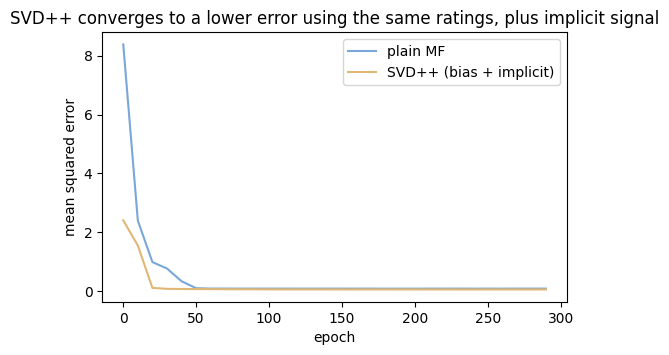

In [9]:

def train_svdpp(R, implicit_sets, k=3, lr=0.02, reg=0.05, epochs=300, seed=0):
    rng = np.random.RandomState(seed)
    n_users, n_items = R.shape
    mu = np.nanmean(R)
    b_u = np.zeros(n_users)
    b_i = np.zeros(n_items)
    P = rng.normal(0, 0.1, (n_users, k))
    Q = rng.normal(0, 0.1, (n_items, k))
    Y = rng.normal(0, 0.1, (n_items, k))  # implicit-feedback item vectors
    observed = np.argwhere(~np.isnan(R))

    history = []
    for epoch in range(epochs):
        rng.shuffle(observed)
        for u, i in observed:
            Nu = implicit_sets[u]
            implicit_term = Y[list(Nu)].sum(axis=0) / np.sqrt(len(Nu)) if Nu else np.zeros(k)
            pu_boosted = P[u] + implicit_term
            pred = mu + b_u[u] + b_i[i] + Q[i] @ pu_boosted
            err = R[u, i] - pred

            b_u[u] += lr * (err - reg * b_u[u])
            b_i[i] += lr * (err - reg * b_i[i])
            P[u]   += lr * (err * Q[i] - reg * P[u])
            Q[i]   += lr * (err * pu_boosted - reg * Q[i])
            if Nu:
                for j in Nu:
                    Y[j] += lr * (err * Q[i] / np.sqrt(len(Nu)) - reg * Y[j])
        if epoch % 10 == 0:
            preds = np.zeros_like(R)
            for uu in range(n_users):
                Nu = implicit_sets[uu]
                imp = Y[list(Nu)].sum(axis=0)/np.sqrt(len(Nu)) if Nu else np.zeros(k)
                preds[uu] = mu + b_u[uu] + b_i + Q @ (P[uu] + imp)
            sq_err = (R[~np.isnan(R)] - preds[~np.isnan(R)]) ** 2
            history.append(sq_err.mean())
    return history

# simulate implicit feedback: "clicked but didn't rate" ~ a couple of random unrated items per user
implicit_sets = []
for u in range(R.shape[0]):
    unrated = list(np.where(np.isnan(R[u]))[0])
    implicit_sets.append(set(np.random.choice(unrated, size=min(2, len(unrated)), replace=False)) if unrated else set())

svdpp_history = train_svdpp(R, implicit_sets)

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(np.arange(len(history))*10, history, color='#7aa7d9', label='plain MF')
ax.plot(np.arange(len(svdpp_history))*10, svdpp_history, color='#e0b774', label='SVD++ (bias + implicit)')
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error"); ax.legend()
ax.set_title("SVD++ converges to a lower error using the same ratings, plus implicit signal")
plt.show()



## 7. The cold start problem — shrinkage for brand-new items

A new item with one 5-star rating shouldn't outrank a well-loved item with 500
ratings averaging 4.8. **Shrinkage** (a Bayesian average) blends an item's own
average with the global average, weighted by how much evidence we actually have:

$$\text{score} = \frac{n\cdot \bar r_{\text{item}} + m\cdot \bar r_{\text{global}}}{n + m}$$

$m$ acts like a "prior strength" — a number of imaginary average-rated votes we
add before trusting the item's own data.


In [10]:

def shrinkage_score(item_avg, item_count, global_avg, m=5):
    return (item_count * item_avg + m * global_avg) / (item_count + m)

global_avg = np.nanmean(R)
examples = pd.DataFrame({
    "item": ["Brand New Release", "Cult Favorite", "Blockbuster"],
    "own_avg_rating": [5.0, 4.9, 4.2],
    "num_ratings": [1, 6, 500],
})
examples["naive_rank_score"] = examples["own_avg_rating"]
examples["shrinkage_score"] = examples.apply(
    lambda row: shrinkage_score(row.own_avg_rating, row.num_ratings, global_avg, m=5), axis=1)
examples.round(2)


,item,own_avg_rating,num_ratings,naive_rank_score,shrinkage_score
0,Brand New Release,5.0,1,5.0,2.87
1,Cult Favorite,4.9,6,4.9,3.78
2,Blockbuster,4.2,500,4.2,4.18



## 8. Implicit feedback & negative sampling (BPR)

We usually only observe *positives* (clicks, watches). Training on positives
alone teaches the trivial "everything is relevant" answer. **Negative sampling**
draws random un-interacted items and trains the model to rank observed positives
above them, using the BPR loss from section 3.


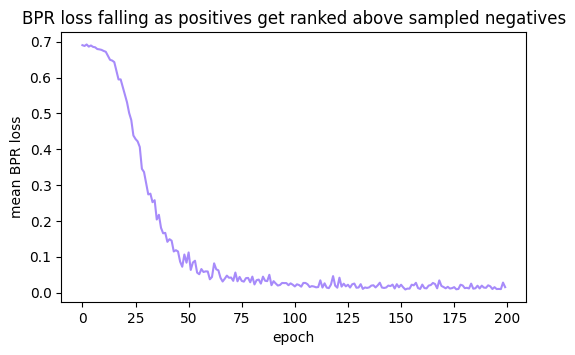

In [11]:

def train_bpr(n_users, n_items, positive_pairs, k=3, lr=0.05, reg=0.01, epochs=200, seed=0):
    rng = np.random.RandomState(seed)
    P = rng.normal(0, 0.1, (n_users, k))
    Q = rng.normal(0, 0.1, (n_items, k))
    all_items = np.arange(n_items)
    pos_by_user = {}
    for u, i in positive_pairs:
        pos_by_user.setdefault(u, set()).add(i)

    loss_history = []
    for epoch in range(epochs):
        rng.shuffle(positive_pairs)
        epoch_loss = 0
        for u, i in positive_pairs:
            j = rng.choice(all_items)
            while j in pos_by_user[u]:
                j = rng.choice(all_items)
            score_pos = P[u] @ Q[i]
            score_neg = P[u] @ Q[j]
            loss = bpr_loss(score_pos, score_neg)
            epoch_loss += loss
            grad = sigmoid(score_neg - score_pos)  # d(loss)/d(score_pos - score_neg) simplifies nicely
            P[u] += lr * (grad * (Q[i] - Q[j]) - reg * P[u])
            Q[i] += lr * (grad * P[u] - reg * Q[i])
            Q[j] += lr * (-grad * P[u] - reg * Q[j])
        loss_history.append(epoch_loss / len(positive_pairs))
    return P, Q, loss_history

# treat rating >= 4 as an implicit "positive"
positive_pairs = [(u, i) for u, i in np.argwhere(~np.isnan(R)) if R[u, i] >= 4]
P_bpr, Q_bpr, bpr_history = train_bpr(R.shape[0], R.shape[1], positive_pairs)

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(bpr_history, color='#a78bfa')
ax.set_xlabel("epoch"); ax.set_ylabel("mean BPR loss")
ax.set_title("BPR loss falling as positives get ranked above sampled negatives")
plt.show()



## 9. Alternating Least Squares (ALS)

Instead of nudging $P$ and $Q$ together with SGD, ALS **freezes one, solves the
other exactly**, then swaps. With $Q$ fixed, finding the best $p_u$ is ordinary
ridge regression — a direct linear-algebra solve, no learning rate required:

$$p_u = (Q^TQ + \lambda I)^{-1}Q^Tr_u$$

and symmetrically for $q_i$ with $P$ fixed. Each half-step is guaranteed not to
increase the loss.


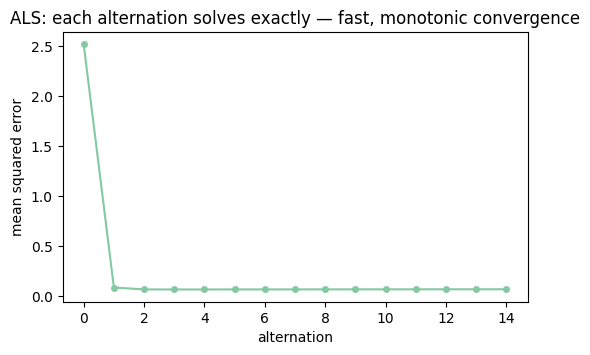

Converged in 15 alternations to MSE=0.0666


In [12]:

def train_als(R, k=3, reg=0.1, iterations=15, seed=0):
    rng = np.random.RandomState(seed)
    n_users, n_items = R.shape
    P = rng.normal(0, 0.1, (n_users, k))
    Q = rng.normal(0, 0.1, (n_items, k))
    mask = ~np.isnan(R)
    R_filled = np.nan_to_num(R, nan=0.0)

    history = []
    for it in range(iterations):
        # fix Q, solve P (row by row, using only rated items)
        for u in range(n_users):
            idx = mask[u]
            Qi = Q[idx]
            A = Qi.T @ Qi + reg * np.eye(k)
            b = Qi.T @ R_filled[u, idx]
            P[u] = np.linalg.solve(A, b)
        # fix P, solve Q (column by column)
        for i in range(n_items):
            idx = mask[:, i]
            Pu = P[idx]
            A = Pu.T @ Pu + reg * np.eye(k)
            b = Pu.T @ R_filled[idx, i]
            Q[i] = np.linalg.solve(A, b)

        preds = P @ Q.T
        sq_err = (R[mask] - preds[mask]) ** 2
        history.append(sq_err.mean())
    return P, Q, history

P_als, Q_als, als_history = train_als(R)

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(als_history, color='#84c9a2', marker='o', ms=4)
ax.set_xlabel("alternation"); ax.set_ylabel("mean squared error")
ax.set_title("ALS: each alternation solves exactly — fast, monotonic convergence")
plt.show()
print(f"Converged in {len(als_history)} alternations to MSE={als_history[-1]:.4f}")



## 10. Neural Collaborative Filtering — a tiny MLP from scratch

MF scores a pair with a fixed dot product. NCF concatenates user & item
embeddings and pushes them through a small neural network, letting the model
learn *any* shape of interaction. Below is a minimal 2-layer network trained with
manual backpropagation, so every gradient is visible:

$$a_1 = \text{ReLU}(W_1[p_u;q_i] + b_1) \qquad \hat y = \sigma(w_2^Ta_1 + b_2)$$


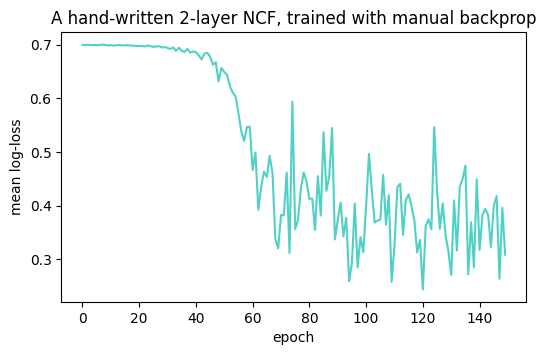

In [13]:

def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)

class TinyNCF:
    def __init__(self, n_users, n_items, emb_dim=4, hidden=8, seed=0):
        rng = np.random.RandomState(seed)
        self.Pu = rng.normal(0, 0.1, (n_users, emb_dim))
        self.Qi = rng.normal(0, 0.1, (n_items, emb_dim))
        self.W1 = rng.normal(0, 0.2, (2*emb_dim, hidden))
        self.b1 = np.zeros(hidden)
        self.w2 = rng.normal(0, 0.2, hidden)
        self.b2 = 0.0

    def forward(self, u, i):
        x = np.concatenate([self.Pu[u], self.Qi[i]])
        z1 = x @ self.W1 + self.b1
        a1 = relu(z1)
        y_hat = sigmoid(a1 @ self.w2 + self.b2)
        return x, z1, a1, y_hat

    def train_step(self, u, i, y, lr=0.05):
        x, z1, a1, y_hat = self.forward(u, i)
        d_out = (y_hat - y)                      # d(log-loss)/d(pre-sigmoid) simplifies to this
        d_w2 = d_out * a1
        d_b2 = d_out
        d_a1 = d_out * self.w2
        d_z1 = d_a1 * relu_deriv(z1)
        d_W1 = np.outer(x, d_z1)
        d_b1 = d_z1
        d_x  = d_z1 @ self.W1.T

        self.w2 -= lr * d_w2; self.b2 -= lr * d_b2
        self.W1 -= lr * d_W1; self.b1 -= lr * d_b1
        self.Pu[u] -= lr * d_x[:len(self.Pu[u])]
        self.Qi[i] -= lr * d_x[len(self.Pu[u]):]
        return log_loss(y, y_hat)

# train on implicit positives (y=1) vs sampled negatives (y=0) — same recipe as BPR, but pointwise
model = TinyNCF(R.shape[0], R.shape[1])
rng = np.random.RandomState(1)
all_items = np.arange(R.shape[1])
loss_hist = []
for epoch in range(150):
    epoch_loss = 0
    for u, i in positive_pairs:
        epoch_loss += model.train_step(u, i, 1.0)
        j = rng.choice(all_items)
        epoch_loss += model.train_step(u, j, 0.0)
    loss_hist.append(epoch_loss / (2*len(positive_pairs)))

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(loss_hist, color='#4fd1c5')
ax.set_xlabel("epoch"); ax.set_ylabel("mean log-loss")
ax.set_title("A hand-written 2-layer NCF, trained with manual backprop")
plt.show()



## 11. DeepFM — the Factorization Machine algebra trick

Scoring every *pair* of features naively costs $O(d^2)$ per prediction — too slow
with many features. The FM reformulation computes the same sum in $O(d\cdot k)$
using one algebraic identity:

$$\sum_{i<j}\langle v_i,v_j\rangle x_ix_j =
\frac{1}{2}\left[\Big(\sum_i v_ix_i\Big)^2 - \sum_i (v_ix_i)^2\right]$$

Let's *prove it numerically* — compute both sides on random data and confirm they
match to floating-point precision.


In [14]:

def fm_naive(x, V):
    d = len(x)
    total = 0.0
    for i in range(d):
        for j in range(i+1, d):
            total += (V[i] @ V[j]) * x[i] * x[j]
    return total

def fm_fast(x, V):
    # V: (d, k) embedding table, x: (d,) feature values
    vx = V * x[:, None]              # scale each embedding row by its feature value
    sum_sq = np.sum(vx, axis=0) ** 2
    sq_sum = np.sum(vx ** 2, axis=0)
    return 0.5 * np.sum(sum_sq - sq_sum)

rng = np.random.RandomState(2)
d, k = 6, 4
x_sample = rng.normal(size=d)
V_sample = rng.normal(size=(d, k))

naive_result = fm_naive(x_sample, V_sample)
fast_result = fm_fast(x_sample, V_sample)
print(f"naive O(d²) pairwise sum : {naive_result:.6f}")
print(f"fast O(d·k) reformulation: {fast_result:.6f}")
print(f"difference: {abs(naive_result - fast_result):.2e}  (should be ~0)")


naive O(d²) pairwise sum : 4.959996
fast O(d·k) reformulation: 4.959996
difference: 0.00e+00  (should be ~0)



## 12. Evaluation metrics — was the list actually good?

$$\text{Precision@K} = \frac{|\text{relevant}\cap\text{top-K}|}{K}
\qquad
\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}, \quad
\text{DCG@K}=\sum_{i=1}^{K}\frac{\text{rel}_i}{\log_2(i+1)}$$

Precision ignores *order*; NDCG's $\log_2(i{+}1)$ discount rewards relevant items
that appear near the top of the list much more than ones buried lower.


In [15]:

def precision_at_k(relevance, k):
    return np.sum(relevance[:k]) / k

def dcg_at_k(relevance, k):
    rel = np.array(relevance[:k], dtype=float)
    discounts = np.log2(np.arange(2, k+2))
    return np.sum(rel / discounts)

def ndcg_at_k(relevance, k):
    dcg = dcg_at_k(relevance, k)
    ideal = dcg_at_k(sorted(relevance, reverse=True), k)
    return dcg / ideal if ideal > 0 else 0.0

list_A = [1, 0, 1, 1, 0]   # hits near the top
list_B = [0, 0, 1, 1, 1]   # same 3 hits, but buried lower

for name, lst in [("List A (hits early)", list_A), ("List B (hits late)", list_B)]:
    print(f"{name}: Precision@5={precision_at_k(lst,5):.2f}  "
          f"NDCG@5={ndcg_at_k(lst,5):.3f}")


List A (hits early): Precision@5=0.60  NDCG@5=0.906
List B (hits late): Precision@5=0.60  NDCG@5=0.618



## 13. Why production systems retrieve, then rank

Scoring every item with a full model for every request doesn't scale. A cheap
similarity search (top-K by dot product) shortlists candidates fast; only that
shortlist gets the expensive model. Let's feel the actual speed difference at a
larger (but still toy) scale.


In [16]:

import time

n_items_big = 200_000
emb_dim = 32
rng = np.random.RandomState(0)
item_embeddings = rng.normal(size=(n_items_big, emb_dim)).astype(np.float32)
query = rng.normal(size=emb_dim).astype(np.float32)

t0 = time.time()
scores = item_embeddings @ query
top_k_idx = np.argpartition(-scores, 200)[:200]   # fast approximate shortlist
t_retrieval = time.time() - t0

t0 = time.time()
full_sorted = np.argsort(-scores)                  # a full, exact sort over everything
t_full_sort = time.time() - t0

print(f"retrieval (top-200 via argpartition) over {n_items_big:,} items: {t_retrieval*1000:.1f} ms")
print(f"full exact sort over the same {n_items_big:,} items:            {t_full_sort*1000:.1f} ms")
print(f"\n→ retrieval only needs to be fast enough to shortlist candidates;")
print(f"  a slow, rich ranking model then only has to look at those {len(top_k_idx)}.")


retrieval (top-200 via argpartition) over 200,000 items: 4.3 ms
full exact sort over the same 200,000 items:            6.9 ms

→ retrieval only needs to be fast enough to shortlist candidates;
  a slow, rich ranking model then only has to look at those 200.



## 14. Diversity — accurate isn't the same as good

$$\text{diversity@K} = 1 - \frac{2}{K(K-1)}\sum_{i<j}\text{sim}(i,j)$$

A high-precision list can still be five near-identical items. Diversity flips
average pairwise similarity into a single "how varied is this list" score.


In [17]:

def diversity_at_k(item_indices, item_features):
    K = len(item_indices)
    if K < 2:
        return 1.0
    sims = []
    for a in range(K):
        for b in range(a+1, K):
            sims.append(cosine_sim(item_features[item_indices[a]], item_features[item_indices[b]]))
    return 1 - np.mean(sims)

narrow_list = [0, 3, 6, 8]   # all action movies (see item_features)
varied_list = [0, 1, 2, 3]   # action, romance, comedy, action

print("Narrow (all-action) list diversity@4:", round(diversity_at_k(narrow_list, item_features), 3))
print("Varied list diversity@4:             ", round(diversity_at_k(varied_list, item_features), 3))


Narrow (all-action) list diversity@4: 0.005
Varied list diversity@4:              0.728



## Summary

| Method | Core math | What it buys you |
|---|---|---|
| Content-Based | cosine similarity | works with zero rating history, per item |
| Collaborative | mean-centered weighted average | no feature engineering needed |
| Matrix Factorization | regularized squared error + SGD | compact latent taste space |
| SVD++ | + bias terms + implicit feedback | squeezes more signal from the same users |
| ALS | closed-form ridge regression, alternated | fast, parallelizable, monotonic convergence |
| Negative Sampling / BPR | pairwise ranking loss | learns from positive-only data |
| NCF | small MLP, backprop | learns non-linear interactions |
| DeepFM | FM algebra trick | automatic pairwise interactions, no manual crosses |
| Precision/NDCG | rank-aware scoring | measures what users actually see |
| Diversity | average pairwise dissimilarity | keeps recommendations from collapsing narrow |

Every implementation above is intentionally small enough to read top to bottom —
swap in the toy `R` matrix for a real ratings table and the same code scales.
